In [15]:
# Let's import the necessary libraries 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import subplots
from pandas import DataFrame
import matplotlib.pylab as plt
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statistics import mean, median
from scipy import stats

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/uber-ride-analytics-dashboard/ncr_ride_bookings.csv
/kaggle/input/uber-ride-analytics-dashboard/Dasboard.gif
/kaggle/input/uber-ride-analytics-dashboard/Uber.pbix


In [16]:
# We received the CSV file.
df=pd.read_csv('/kaggle/input/uber-ride-analytics-dashboard/ncr_ride_bookings.csv')

In [17]:
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [18]:
df.tail()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI
149999,2024-03-10,15:38:03,"""CNR3447390""",Completed,"""CID4108667""",Premier Sedan,Ashok Park Main,Gurgaon Sector 29,3.5,33.7,...,NaN,NaN,NaN,NaN,NaN,806.0,21.19,4.6,4.9,Credit Card


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Avg VTAT,139500.0,8.456352,3.773564,2.0,5.30,8.30,11.30,20.0
Avg CTAT,102000.0,29.149636,8.902577,10.0,21.60,28.80,36.80,45.0
Cancelled Rides by Customer,10500.0,1.000000,0.000000,1.0,1.00,1.00,1.00,1.0
Cancelled Rides by Driver,27000.0,1.000000,0.000000,1.0,1.00,1.00,1.00,1.0
Incomplete Rides,9000.0,1.000000,0.000000,1.0,1.00,1.00,1.00,1.0
Booking Value,102000.0,508.295912,395.805774,50.0,234.00,414.00,689.00,4277.0
Ride Distance,102000.0,24.637012,14.002138,1.0,12.46,23.72,36.82,50.0
Driver Ratings,93000.0,4.230992,0.436871,3.0,4.10,4.30,4.60,5.0
Customer Rating,93000.0,4.404584,0.437819,3.0,4.20,4.50,4.80,5.0


In [21]:
df.dtypes

Date                                  object
Time                                  object
Booking ID                            object
Booking Status                        object
Customer ID                           object
Vehicle Type                          object
Pickup Location                       object
Drop Location                         object
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer     object
Cancelled Rides by Driver            float64
Driver Cancellation Reason            object
Incomplete Rides                     float64
Incomplete Rides Reason               object
Booking Value                        float64
Ride Distance                        float64
Driver Ratings                       float64
Customer Rating                      float64
Payment Method                        object
dtype: object

In [22]:
# Organizing Categories
df_Float=df.select_dtypes(include=['float64'])
df_Object=df.select_dtypes(include=['object'])
print("Categories have been successfully organized.")
print("-"*100)

Categories have been successfully organized.
----------------------------------------------------------------------------------------------------


In [23]:
# Checking for missing values
Missing_Values=df.isnull().sum()
if Missing_Values.sum()>0:
    print("Missing Values Detected:\n", Missing_Values)
else:  
    print("No Missing Values Detected")
print("-"*100)

df['Incomplete Rides'] = df['Incomplete Rides'].fillna(0.0)

for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype=='float64':
            median=df[col].median()
            df[col]=df[col].fillna(median)
            print(f"Missing Values removed that be data.type 'Float64'")
        elif df[col].dtype=='object':
            mod=df[col].mode()[0]
            df[col]=df[col].fillna(mod)
            print(f"Missing Values removed that be data.type 'Object'")
print(df.isnull().sum())
print("-"*100)


Missing Values Detected:
 Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64
-------------------------------------

In [24]:
# Checking for duplicates
Duplicates=df.duplicated().sum()
if Duplicates>0:
    print("Duplicates Detected:", Duplicates)
    df=df.drop_duplicates()
    print("Duplicates Removed. New shape:", df.shape)
else:
    print("No Duplicates Detected")
print("-"*100)

No Duplicates Detected
----------------------------------------------------------------------------------------------------


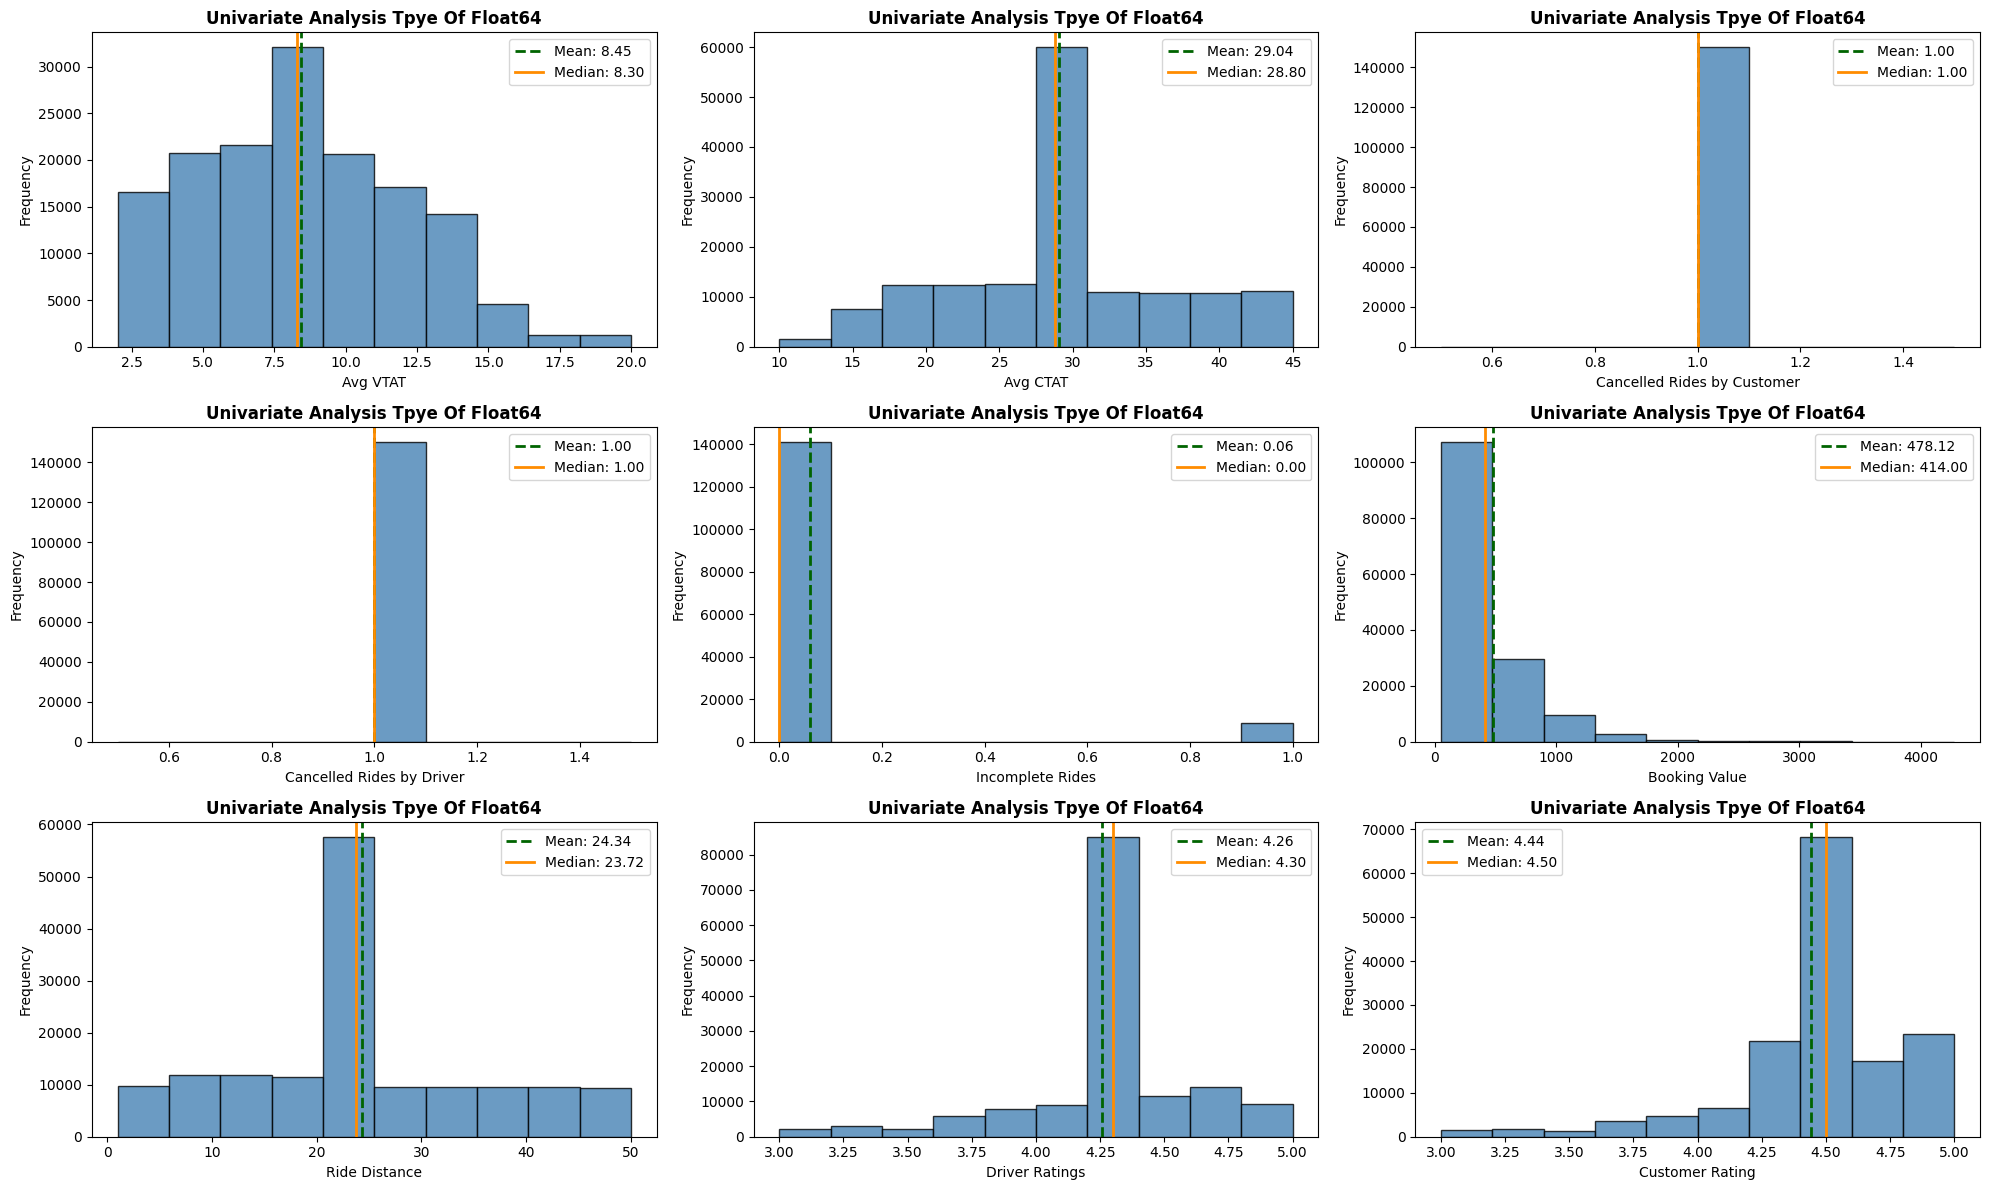

----------------------------------------------------------------------------------------------------

SkewnessOfFeatures:
Incomplete Rides               3.705506
Booking Value                  2.968045
Avg VTAT                       0.326852
Ride Distance                  0.231329
Avg CTAT                       0.101300
Cancelled Rides by Customer    0.000000
Cancelled Rides by Driver      0.000000
Driver Ratings                -1.046081
Customer Rating               -1.400855
dtype: float64
----------------------------------------------------------------------------------------------------


In [25]:
# Univariate analysis for Float64;
num_plots=len(df_Float.columns)
rows=int(np.ceil(num_plots/3))

fig,axes=plt.subplots(rows,3,figsize=(20,4*rows))
axes=axes.ravel()

for index,col in enumerate(df_Float.columns):
    if index>=len(axes):
        break
    axes[index].hist(df[col],bins=10,color="steelblue",edgecolor='black',alpha=0.8)
    axes[index].set_title("Univariate Analysis Tpye Of Float64",fontsize=12,fontweight='bold',color='black')
    axes[index].set_xlabel(col)
    axes[index].set_ylabel("Frequency")

    mean_value=df[col].mean()
    median_value=df[col].median()
    axes[index].axvline(mean_value,color="darkgreen",linestyle="--",linewidth=2,label=f"Mean: {mean_value:.2f}")
    axes[index].axvline(median_value,color="darkorange",linestyle="-",linewidth=2,label=f"Median: {median_value:.2f}")
    axes[index].legend()
for i in range(num_plots,len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig("Univariate Analysis.png",dpi=300,bbox_inches='tight')
plt.show()
print("-"*100)

skew=df.skew(numeric_only=True)
print("\nSkewnessOfFeatures:")
print(skew.sort_values(ascending=False))
print("-"*100)

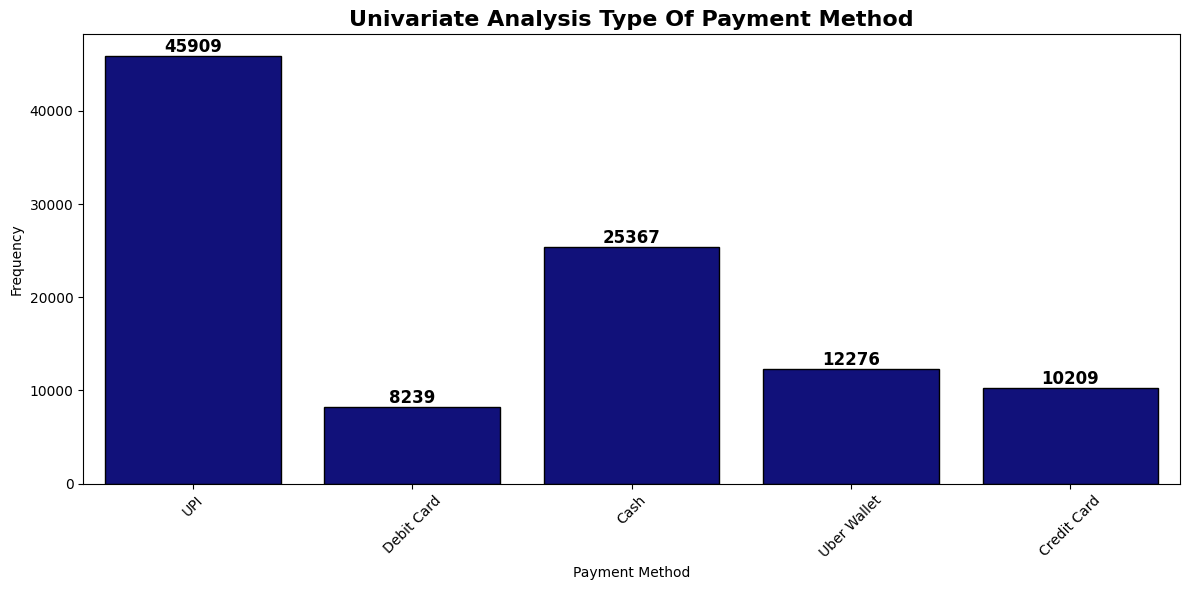

----------------------------------------------------------------------------------------------------


In [26]:
# Univariate analysis for Payment Method;
plt.figure(figsize=(12,6))

sns.countplot(x=df_Object['Payment Method'],color="darkblue",edgecolor="black")
plt.title("Univariate Analysis Type Of Payment Method",fontsize=16,fontweight='bold',color='black')
plt.xlabel("Payment Method")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

for p in plt.gca().patches:
    height=p.get_height()
    if height>0:
        plt.text(p.get_x()+ p.get_width() / 2., height+5,f'{int(height)}',ha='center',va='bottom',fontsize=12,fontweight='bold')

plt.tight_layout()
plt.savefig("Univariate Analysis2.png",dpi=300,bbox_inches='tight')
plt.show()
print("-"*100)

Vehicle Types Plot;
----------------------------------------------------------------------------------------------------


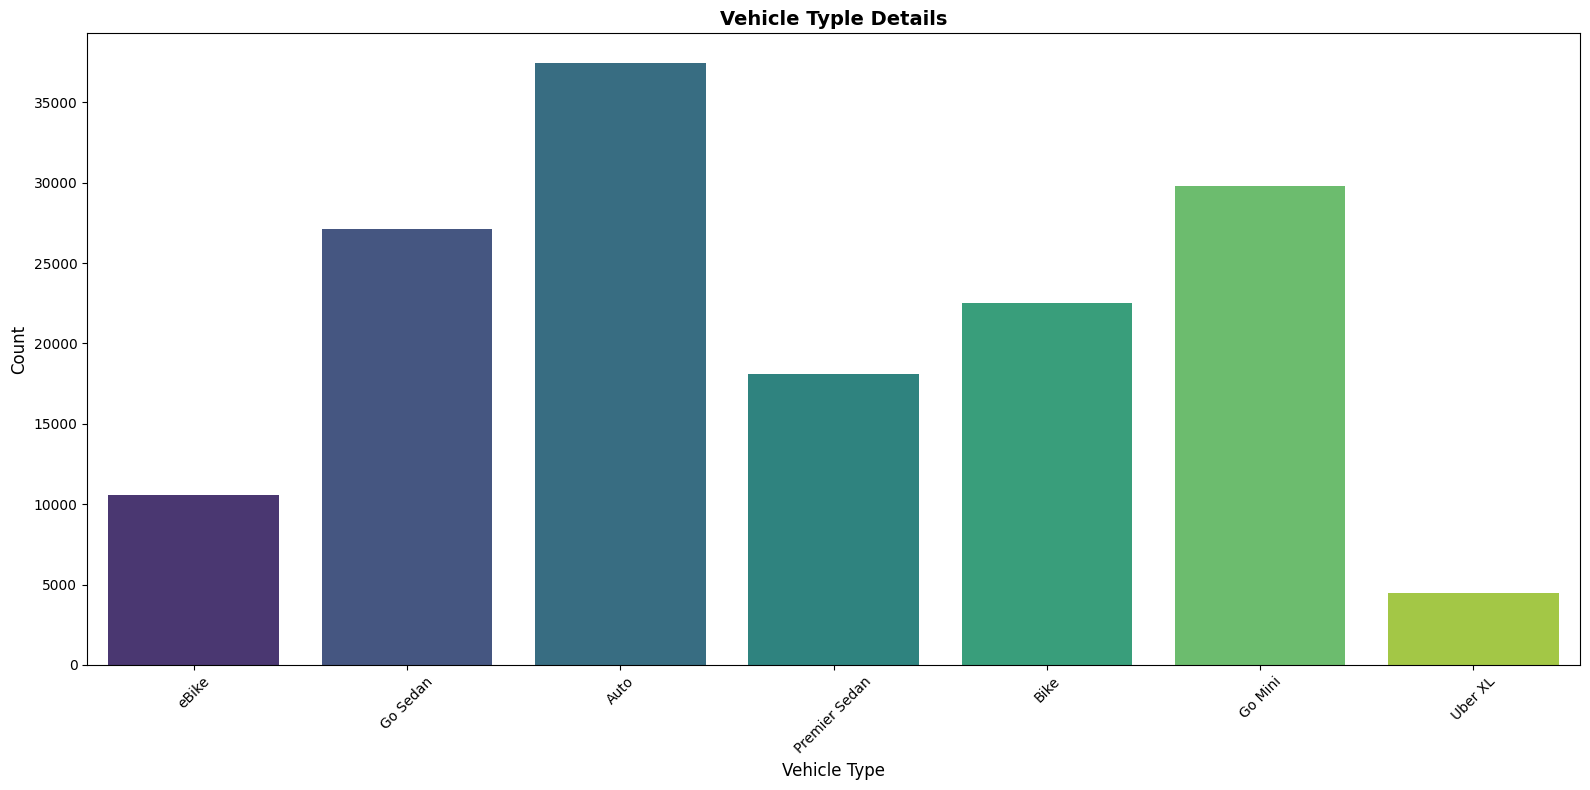

In [27]:
# Vehicle Type Visualization;
print("Vehicle Types Plot;")
print("-"*100)

Vehicle_Categories=df['Vehicle Type']
Vehicle_Categories_Values=Vehicle_Categories.value_counts().sort_index()

plt.figure(figsize=(16,8))
plt.title("Vehicle Typle Details",fontsize=14,fontweight='bold')
sns.countplot(data=df,x='Vehicle Type',palette="viridis") 
plt.xlabel("Vehicle Type",fontsize=12)    
plt.ylabel("Count",fontsize=12)    
plt.xticks(rotation=45) 
plt.tight_layout()
   
plt.savefig("Vehicle Type.png",dpi=300,bbox_inches='tight')
plt.show()

Booking Status Pie Plot;
----------------------------------------------------------------------------------------------------


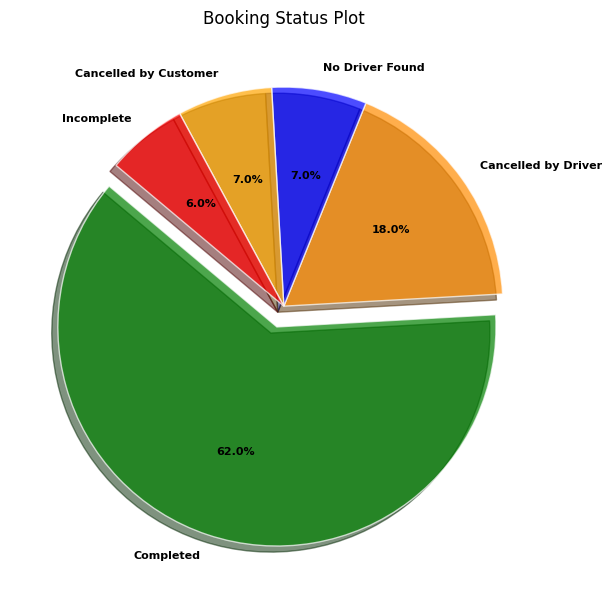

----------------------------------------------------------------------------------------------------


In [28]:
# Booking_Status Pie Plot;
print("Booking Status Pie Plot;")
print("-"*100)

status_counts=df['Booking Status'].value_counts()
values=status_counts.values
labels=status_counts.index
colors=['green','darkorange','blue','orange','red']
explode=[0.1,0,0,0,0]

plt.figure(figsize=(12,6))
plt.pie(values,labels=labels,autopct='%1.1f%%', startangle=140,shadow=True,wedgeprops={'edgecolor':'white','alpha':0.7},textprops={'fontsize':8,'fontweight':'bold'},colors=colors,explode=explode)
plt.title("Booking Status Plot")
plt.tight_layout()
plt.savefig("Booking Status Pie.png",dpi=300,bbox_inches='tight')
plt.show()
print("-"*100)

Pickup Locations and Drop Locations;
----------------------------------------------------------------------------------------------------
Pickup Location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
Madipur             919
AIIMS               918
Mehrauli            915
Dwarka Sector 21    914
Pataudi Chowk       907
Name: count, dtype: int64
Drop Location
Ashram                936
Basai Dhankot         917
Lok Kalyan Marg       916
Narsinghpur           913
Cyber Hub             912
Kalkaji               912
Kashmere Gate ISBT    909
Udyog Vihar           906
Lajpat Nagar          904
Nehru Place           902
Name: count, dtype: int64


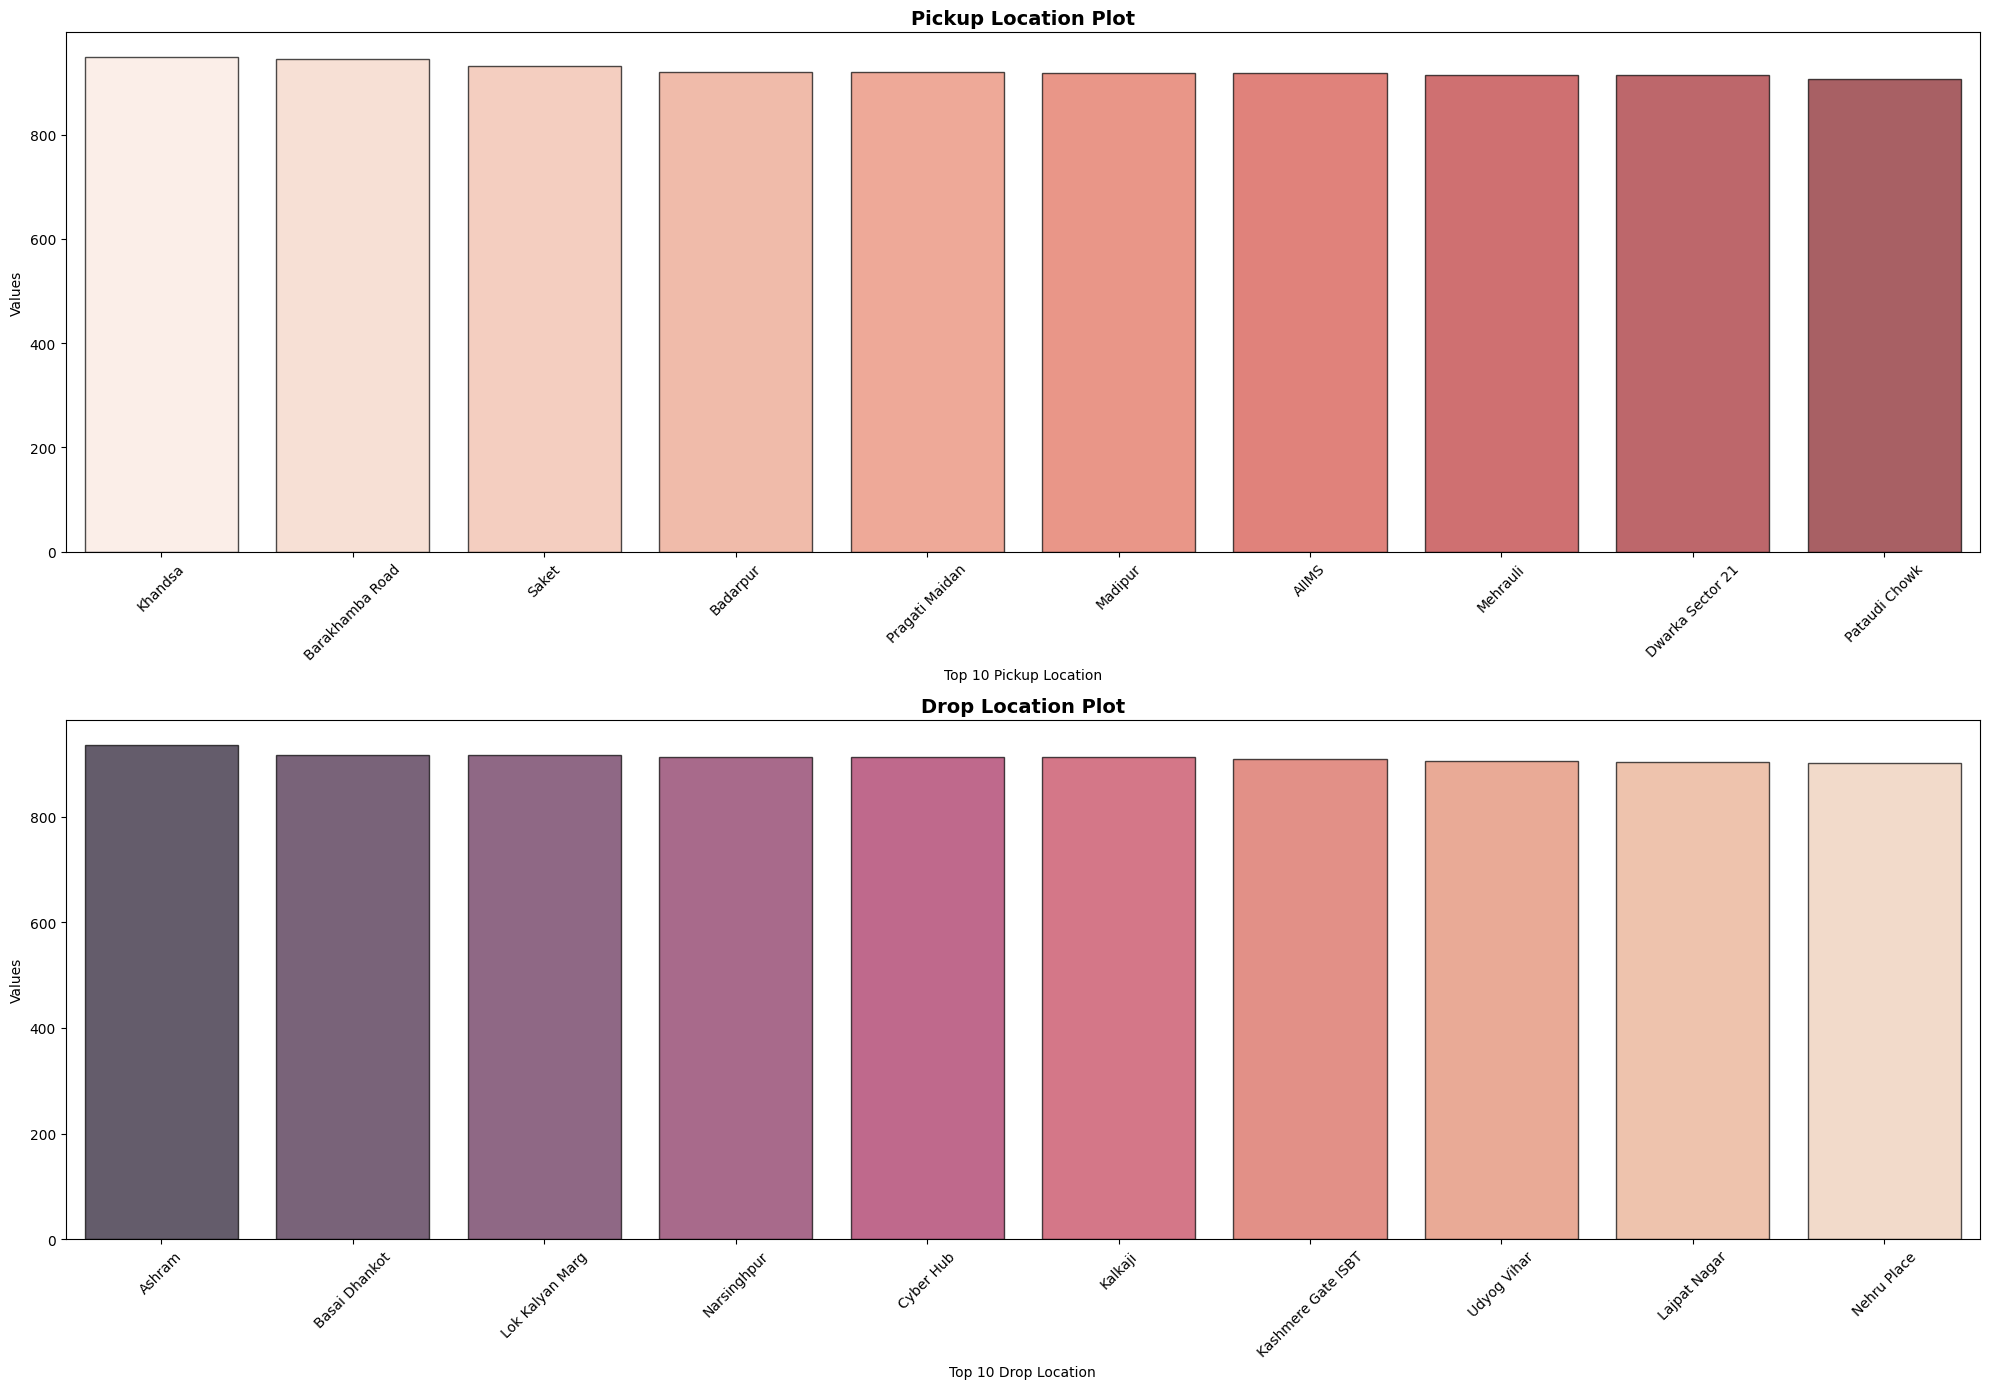

----------------------------------------------------------------------------------------------------


In [45]:
# Top 10 Pickup and Drop Location Plots;
Pickup_Location_Values=df['Pickup Location'].value_counts()
Drop_Location_Values=df['Drop Location'].value_counts()
top_10_PickupLocation=Pickup_Location_Values.head(10)
top_10_DropLocation=Drop_Location_Values.head(10)

print("Pickup Locations and Drop Locations;")
print("-"*100)
print(top_10_PickupLocation)
print(top_10_DropLocation)

fig,axes=plt.subplots(2,1,figsize=(20,14))
axes=axes.ravel()

sns.barplot(x=top_10_PickupLocation.index,y=top_10_PickupLocation.values,ax=axes[0],palette='Reds',edgecolor='black',linewidth=1,alpha=0.7)
axes[0].set_title("Pickup Location Plot",fontsize=14,fontweight='bold')
axes[0].set_xlabel("Top 10 Pickup Location",fontsize=10)
axes[0].set_ylabel("Values",fontsize=10)
axes[0].tick_params(axis='x',rotation=45,labelsize=10)

sns.barplot(x=top_10_DropLocation.index,y=top_10_DropLocation.values,ax=axes[1],palette='rocket',edgecolor='black',linewidth=1,alpha=0.7)
axes[1].set_title("Drop Location Plot",fontsize=14,fontweight='bold')
axes[1].set_xlabel("Top 10 Drop Location",fontsize=10)
axes[1].set_ylabel("Values",fontsize=10)
axes[1].tick_params(axis='x',rotation=45,labelsize=10)

plt.tight_layout()
plt.savefig("Top and Least 10 Pickup and Drop Location Plots.png",dpi=300,bbox_inches='tight')
plt.show()
print("-"*100)

Driver Ratings And Customer Rating Plots;
----------------------------------------------------------------------------------------------------
[4.3 4.9 4.6 4.1 4.  4.4 4.2 4.7 3.8 5.  3.7 3.1 4.5 3.9 3.3 3.2 4.8 3.6
 3.5 3.4 3. ]
[4.5 4.9 5.  4.3 4.6 4.1 4.2 4.7 4.4 3.6 3.3 3.8 3.7 4.8 3.9 3.4 3.2 3.1
 4.  3.  3.5]


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_36/962510679.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


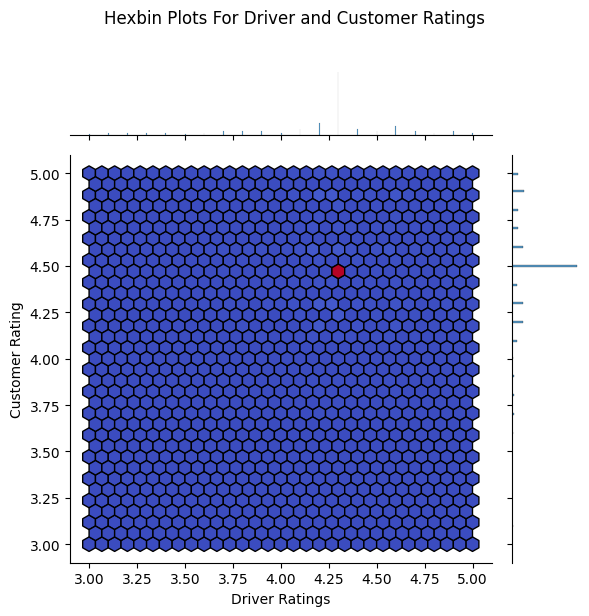

----------------------------------------------------------------------------------------------------


In [30]:
# Driver Ratings and Customer Rating Plots;
print("Driver Ratings And Customer Rating Plots;")
print("-"*100)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

df['Driver Ratings']=pd.to_numeric(df['Driver Ratings'],errors='coerce')
df['Customer Rating']=pd.to_numeric(df['Customer Rating'],errors='coerce')

print(df['Driver Ratings'].unique())
print(df['Customer Rating'].unique())

g=sns.jointplot(x='Driver Ratings',y='Customer Rating',data=df,kind='hex',cmap='coolwarm',gridsize=30,edgecolor='black')
g.fig.suptitle("Hexbin Plots For Driver and Customer Ratings",y=1.02,fontsize=12)
g.set_axis_labels("Driver Ratings","Customer Rating",fontsize=10)

plt.tight_layout()
plt.savefig("Driver and Customer Ratings.png",dpi=300,bbox_inches='tight')
plt.show()
print("-"*100)


Customer Ratings based on Car selection;
----------------------------------------------------------------------------------------------------


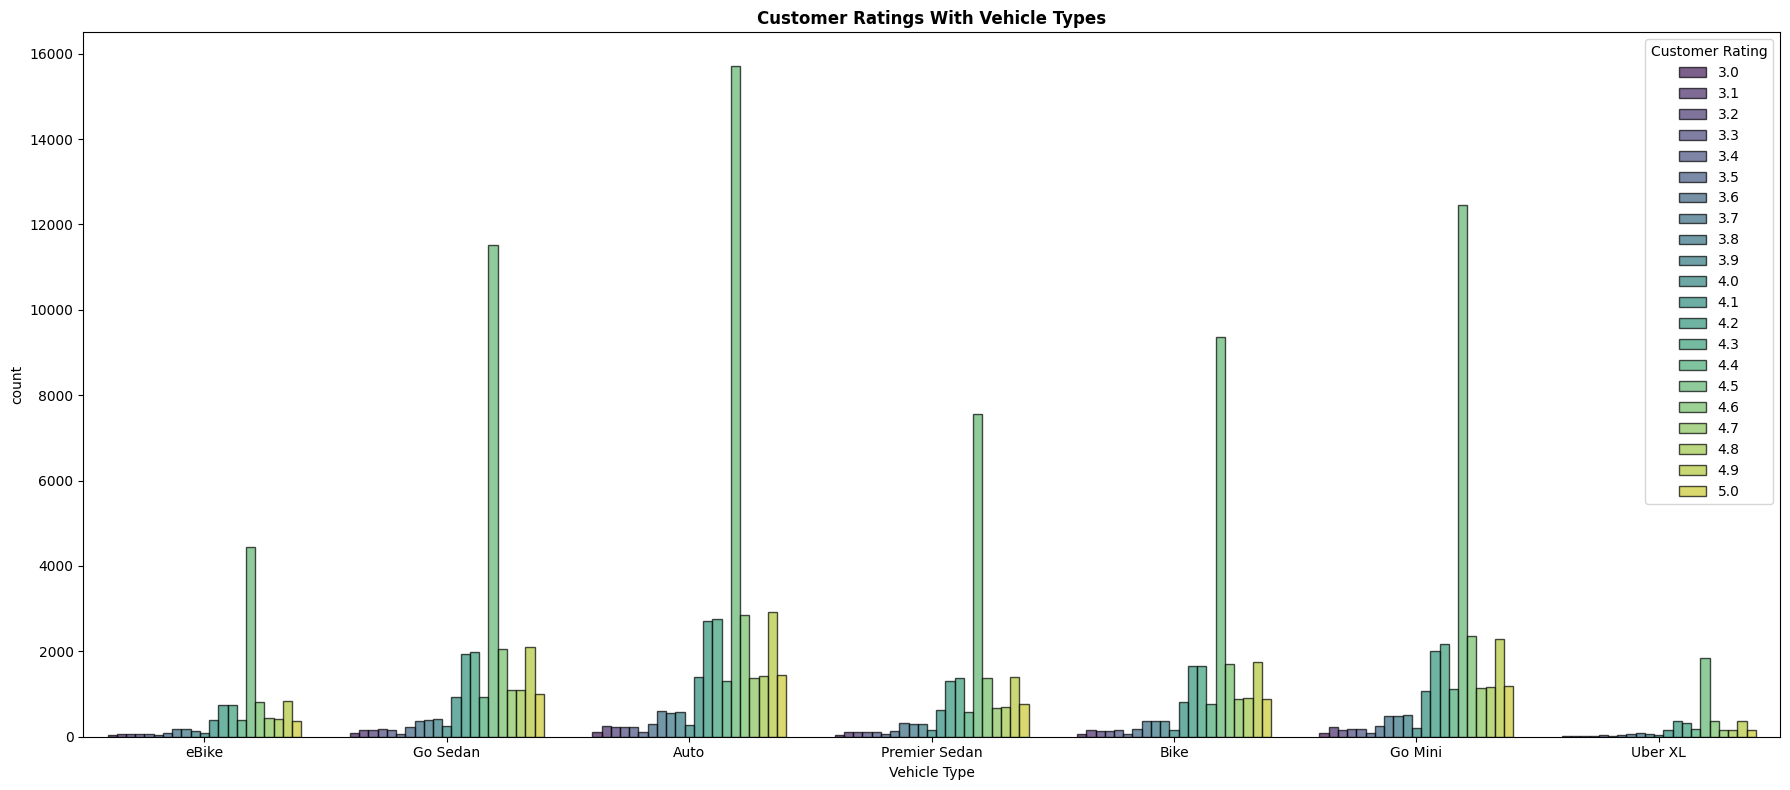

----------------------------------------------------------------------------------------------------


In [31]:
# Customer Ratings with Car Selection;
print("Customer Ratings based on Car selection;")
print("-"*100)

plt.figure(figsize=(18,8))
sns.countplot(x=df['Vehicle Type'],hue=df['Customer Rating'],data=df,orient='h',palette="viridis",edgecolor='black',linewidth=1,alpha=0.7)
plt.title("Customer Ratings With Vehicle Types",fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig("Customer Ratings and Vehicle Type.png",dpi=300,bbox_inches='tight')
plt.show()
print("-"*100)

InComplete Rides Pie Plots;
----------------------------------------------------------------------------------------------------
[0. 1.]
Incomplete Rides
0.0    141000
1.0      9000
Name: count, dtype: int64


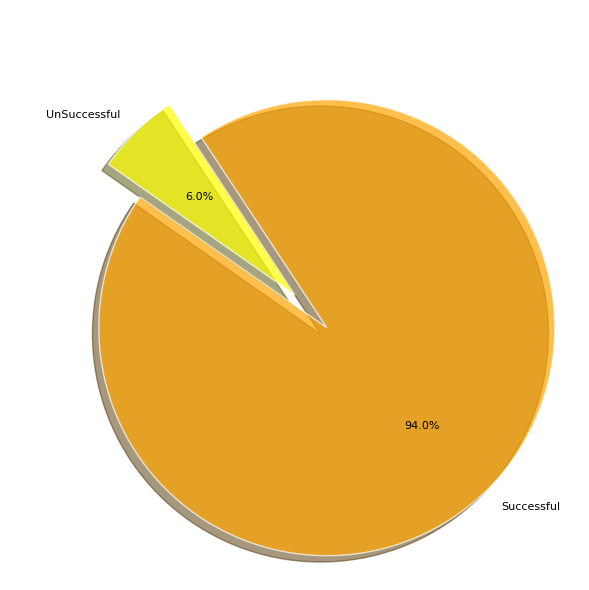

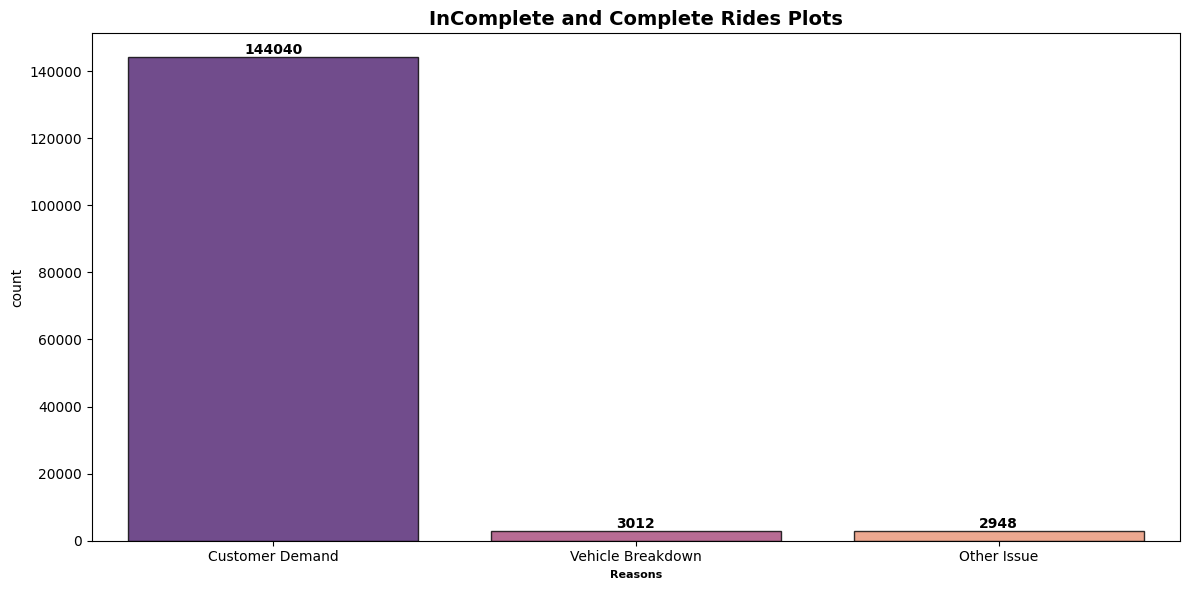

----------------------------------------------------------------------------------------------------


In [32]:
# InComplete Rides Pie Plots;
print("InComplete Rides Pie Plots;")
print("-"*100)

df['Incomplete Rides'] = pd.to_numeric(df['Incomplete Rides'], errors='coerce')
print(df['Incomplete Rides'].unique())
incomplete_counts = df['Incomplete Rides'].value_counts()
print(incomplete_counts)

labels=incomplete_counts.index.map({0.0: 'Successful', 1.0: 'UnSuccessful'})
values=incomplete_counts.values
colors=["orange","yellow"]
explode=[0.2]+[0]*(len(values)-1)

plt.subplots(figsize=(12,6))
plt.pie(values,labels=labels,explode=explode,autopct='%1.1f%%',startangle=145,shadow=True,wedgeprops={'edgecolor':'white','alpha':0.7},textprops={'fontsize':8},colors=colors)
df['Incomplete Rides Reason']=df['Incomplete Rides Reason'].fillna("Unknown")
queue=df['Incomplete Rides Reason'].value_counts().index
queue2=df['Incomplete Rides Reason'].value_counts().values

plt.tight_layout()
plt.savefig("Successful Rate.png",dpi=300,bbox_inches='tight')
plt.show()

fig,ax=plt.subplots(figsize=(12,6))
sns.countplot(data=df,x='Incomplete Rides Reason',palette="magma",edgecolor='black',linewidth=1,alpha=0.8)
ax.set_xlabel("Reasons",fontsize=8,fontweight='bold')
for v in ax.patches:
    ax.text(v.get_x()+v.get_width()/2.,v.get_height(),f'{int(v.get_height())}',ha='center',va='bottom',fontsize=10,fontweight='bold')

plt.savefig("InComplete Reasons.png",dpi=300,bbox_inches='tight')
plt.title("InComplete and Complete Rides Plots",fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()
print("-"*100)

Reasons For Cancelling by Driver or Customer;
----------------------------------------------------------------------------------------------------


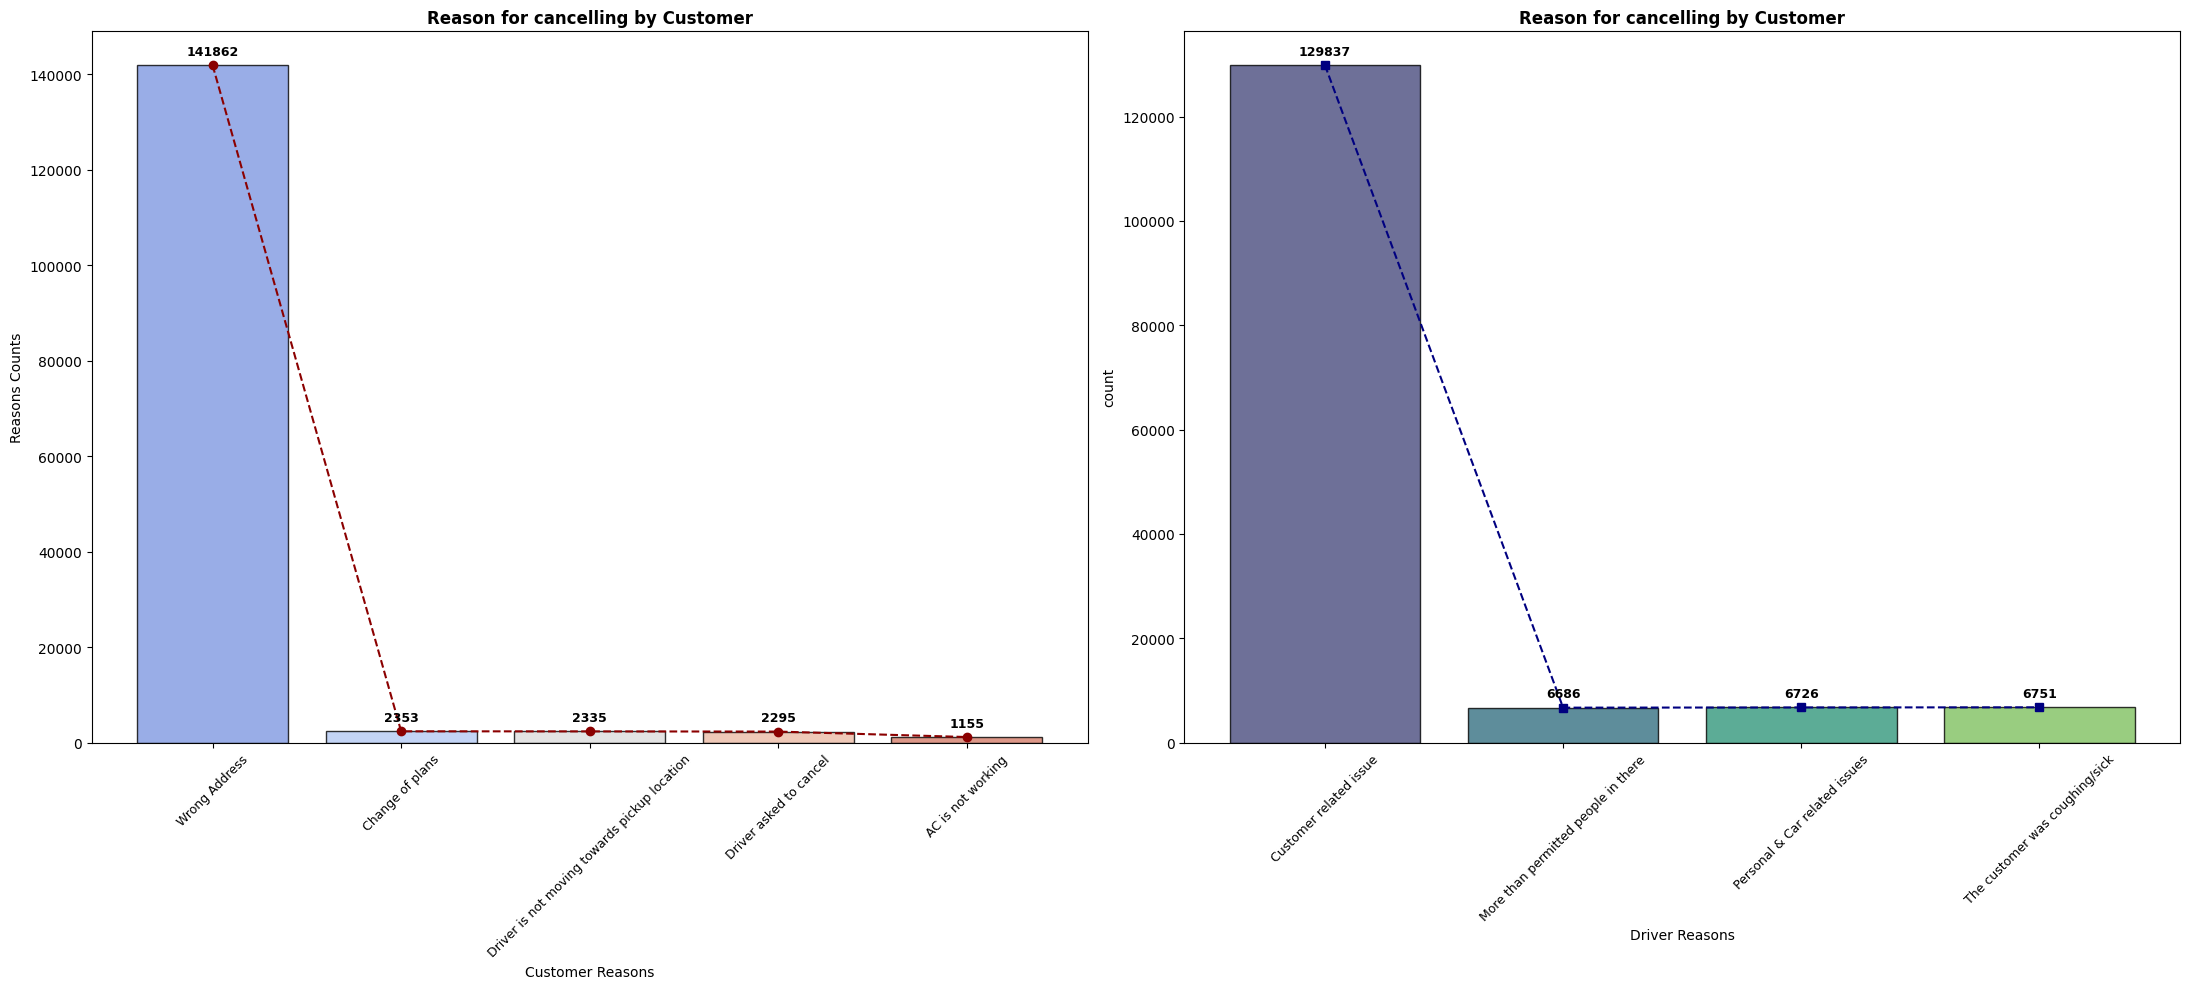

----------------------------------------------------------------------------------------------------
Reason for cancelling by Customer
Wrong Address                                   141862
Change of plans                                   2353
Driver is not moving towards pickup location      2335
Driver asked to cancel                            2295
AC is not working                                 1155
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Driver Cancellation Reason
Customer related issue                 129837
The customer was coughing/sick           6751
Personal & Car related issues            6726
More than permitted people in there      6686
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------


In [33]:
# Reasons for cancelling by Driver or Customer;
print("Reasons For Cancelling by Driver or Customer;")
print("-"*100)

df_customer=df["Reason for cancelling by Customer"].fillna("Unkown")
df_driver=df["Driver Cancellation Reason"].fillna("Unkown")

customer_count = df_customer.value_counts()
plot_order_customer = customer_count.index

driver_count=df_driver.value_counts().sort_index()
plot_order_driver = driver_count.index

customer_line_data = customer_count.loc[plot_order_customer] 
driver_line_data = driver_count.loc[plot_order_driver] 


fig,ax=plt.subplots(1,2,figsize=(22,10))
customer_plot=sns.countplot(x=df_customer,palette="coolwarm",edgecolor="black",alpha=0.8,linewidth=1,ax=ax[0],order=plot_order_customer)
ax[0].set_title("Reason for cancelling by Customer",fontsize=12,fontweight='bold')
ax[0].set_xlabel("Customer Reasons",fontsize=10)
ax[0].set_ylabel("Reasons Counts",fontsize=10)
ax[0].tick_params(axis='x',rotation=45,labelsize=9)
ax[0].plot(customer_line_data.index,customer_line_data.values,marker="o",color="darkred",linestyle="--")

for p in customer_plot.patches:
    customer_plot.annotate(f'{int(p.get_height())}',(p.get_x()+p.get_width()/2.,p.get_height()),ha="center",va="center",xytext=(0,10),textcoords='offset points',fontweight="bold",fontsize=9)

driver_plot=sns.countplot(x=df_driver,palette="viridis",edgecolor="black",alpha=0.8,linewidth=1,ax=ax[1],order=plot_order_driver)
ax[1].set_title("Reason for cancelling by Customer",fontsize=12,fontweight='bold')
ax[1].set_xlabel("Driver Reasons",fontsize=10)
ax[1].tick_params(axis='x',rotation=45,labelsize=9)
ax[1].plot(driver_line_data.index,driver_line_data.values,marker="s",color="navy",linestyle="--")

for p in driver_plot.patches:
    driver_plot.annotate(f'{int(p.get_height())}',(p.get_x()+p.get_width()/2.,p.get_height()),ha="center",va="center",xytext=(0,10),textcoords='offset points',fontweight="bold",fontsize=9)

plt.tight_layout()
plt.savefig("Reasons for cancelling by Driver and Customer.png",dpi=300,bbox_inches='tight')
plt.show()
print("-"*100)

print(df_customer.value_counts())
print("-"*100)
print(df_driver.value_counts())
print("-"*100)


Driver and Customer Ratings Relationship Plots;
----------------------------------------------------------------------------------------------------
Correlation: 0.01


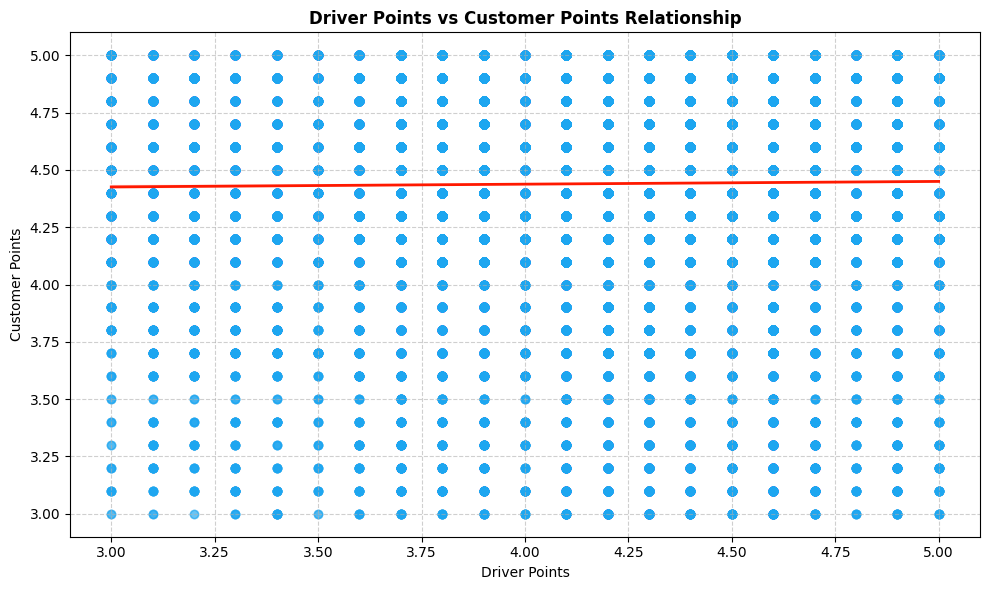

----------------------------------------------------------------------------------------------------


In [34]:
# Driver and Customer Ratings Relationship;
print("Driver and Customer Ratings Relationship Plots;")
print("-"*100)

ratings_df = df.dropna(subset=['Driver Ratings', 'Customer Rating', 'Ride Distance', 'Booking Value']).copy()
ratings_df['Driver Ratings'] = pd.to_numeric(ratings_df['Driver Ratings'])
ratings_df['Customer Rating'] = pd.to_numeric(ratings_df['Customer Rating'])

correlation = ratings_df['Driver Ratings'].corr(ratings_df['Customer Rating'])
print(f"Correlation: {correlation:.2f}")

plt.figure(figsize=(10,6))

sns.regplot(data=ratings_df, x='Driver Ratings', y='Customer Rating',
            scatter_kws={'alpha':0.3, 'color':"#1da6f0"},
            line_kws={'color':"#FF1900", 'linewidth':2})
plt.title('Driver Points vs Customer Points Relationship',fontsize=12,fontweight='bold')
plt.xlabel("Driver Points",fontsize=10)
plt.ylabel("Customer Points",fontsize=10)
plt.grid(True,linestyle="--",alpha=0.6)

plt.tight_layout()
plt.savefig("Driver and Customer Points Relationship.png",dpi=300,bbox_inches='tight')
plt.show()
print("-"*100)

Points and Other Feature Relationship Plots;
----------------------------------------------------------------------------------------------------


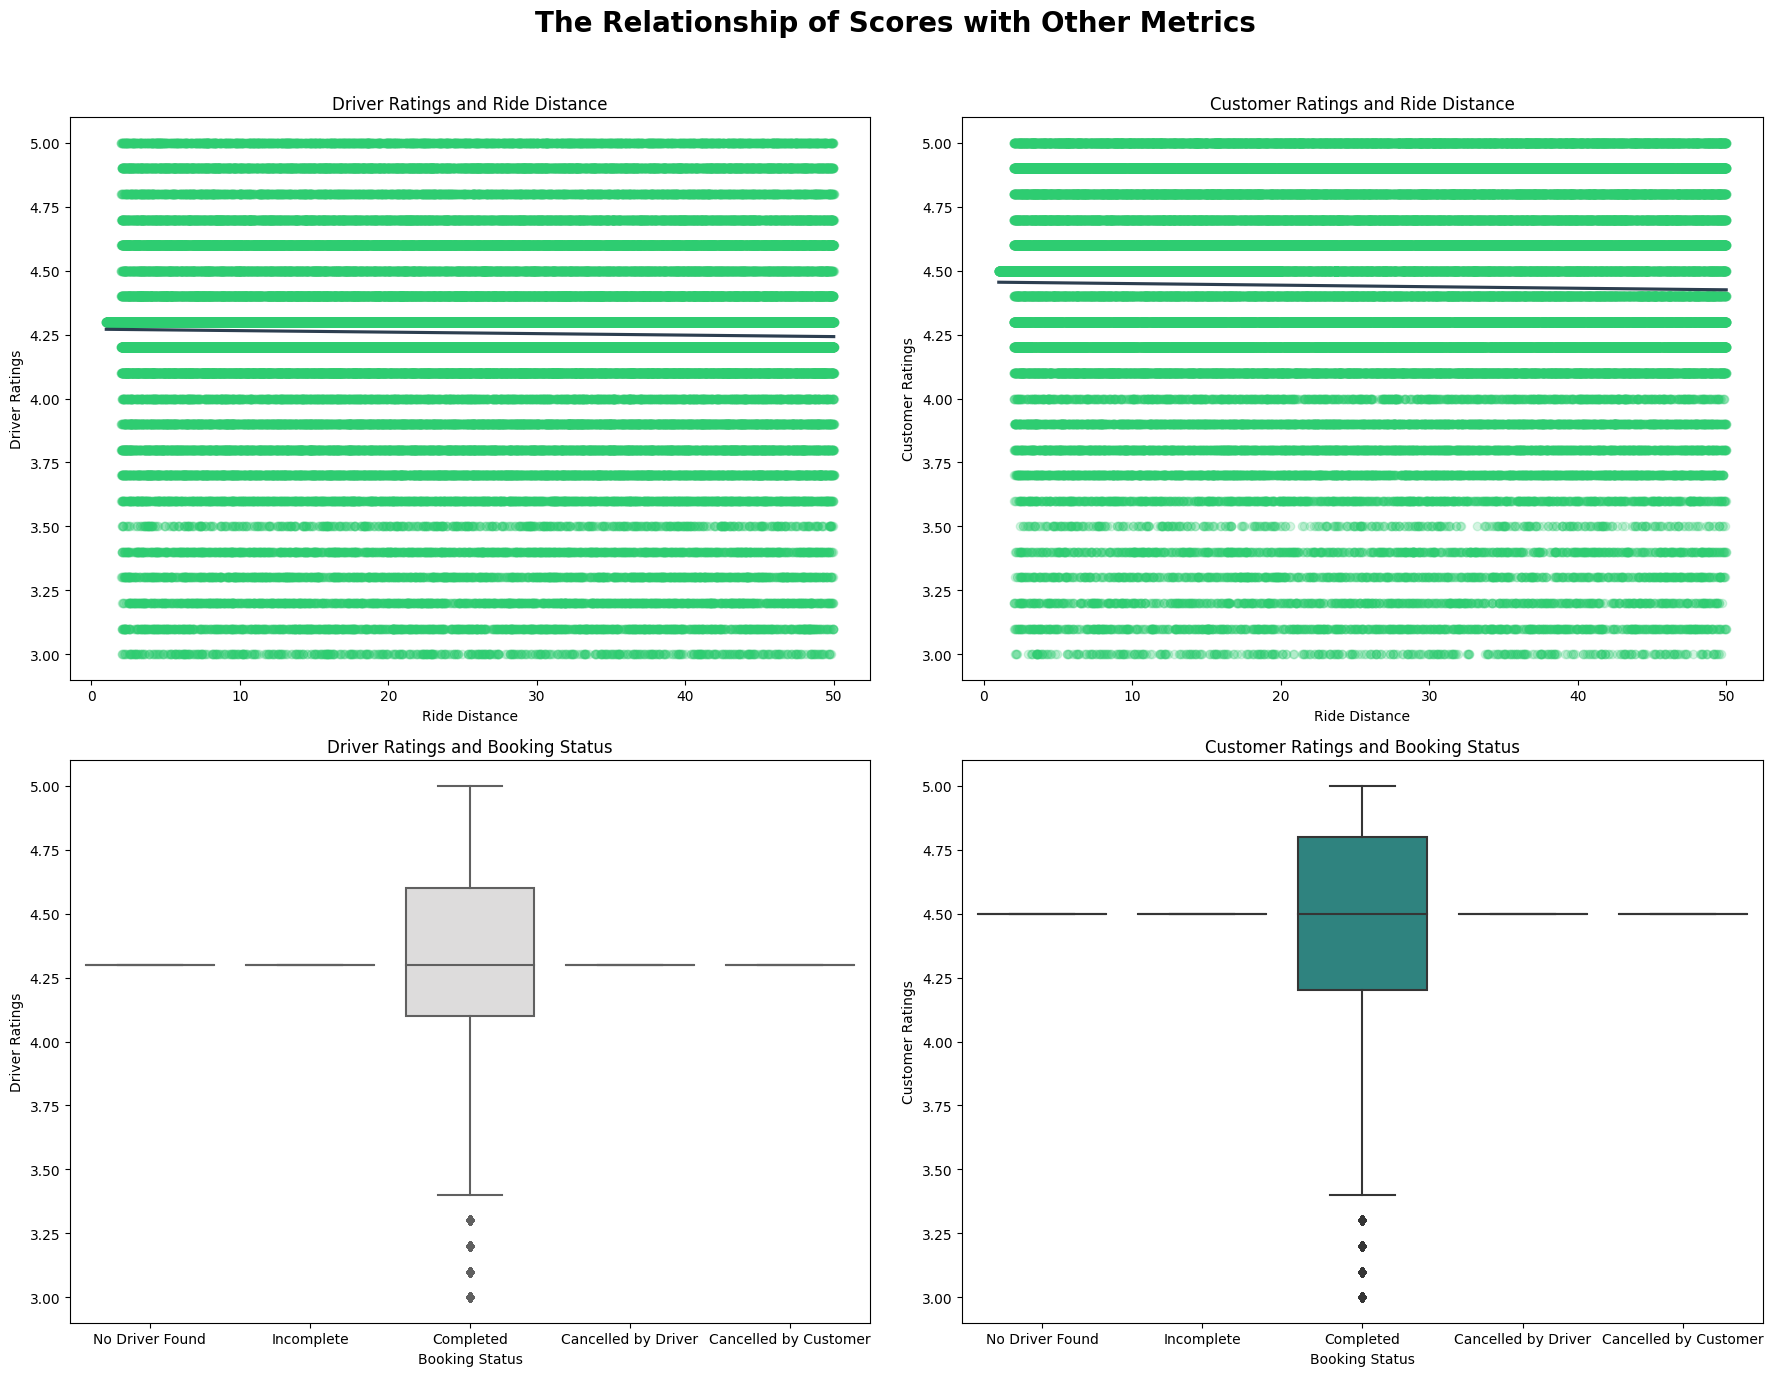

----------------------------------------------------------------------------------------------------


In [35]:
# Points and Other Feature Relationship;
print("Points and Other Feature Relationship Plots;")
print("-"*100)

fig,axes=plt.subplots(2,2,figsize=(18, 14))
fig.suptitle('The Relationship of Scores with Other Metrics', fontsize=20, fontweight='bold')

sns.regplot(ax=axes[0,0], data=ratings_df, x='Ride Distance', y='Driver Ratings',
            scatter_kws={'alpha':0.2, 'color':'#2ecc71'}, line_kws={'color':'#2c3e50'})
axes[0,0].set_title("Driver Ratings and Ride Distance")
axes[0,0].set_xlabel("Ride Distance")
axes[0,0].set_ylabel("Driver Ratings")

sns.regplot(ax=axes[0,1], data=ratings_df, x='Ride Distance', y='Customer Rating',
            scatter_kws={'alpha':0.2,'color':'#2ecc71'}, line_kws={'color':'#2c3e50'})
axes[0,1].set_title("Customer Ratings and Ride Distance")
axes[0,1].set_xlabel("Ride Distance")
axes[0,1].set_ylabel("Customer Ratings")

sns.boxplot(ax=axes[1,0], data=ratings_df, x='Booking Status', y='Driver Ratings',palette="coolwarm")
axes[1,0].set_title("Driver Ratings and Booking Status")
axes[1,0].set_xlabel("Booking Status")
axes[1,0].set_ylabel("Driver Ratings")

sns.boxplot(ax=axes[1,1], data=ratings_df, x='Booking Status', y='Customer Rating',palette="viridis")
axes[1,1].set_title("Customer Ratings and Booking Status")
axes[1,1].set_xlabel("Booking Status")
axes[1,1].set_ylabel("Customer Ratings")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("Points and Other Feature Relationship.png",dpi=300,bbox_inches='tight')
plt.show()
print("-"*100)


Cancelled Riders by Customers;
----------------------------------------------------------------------------------------------------


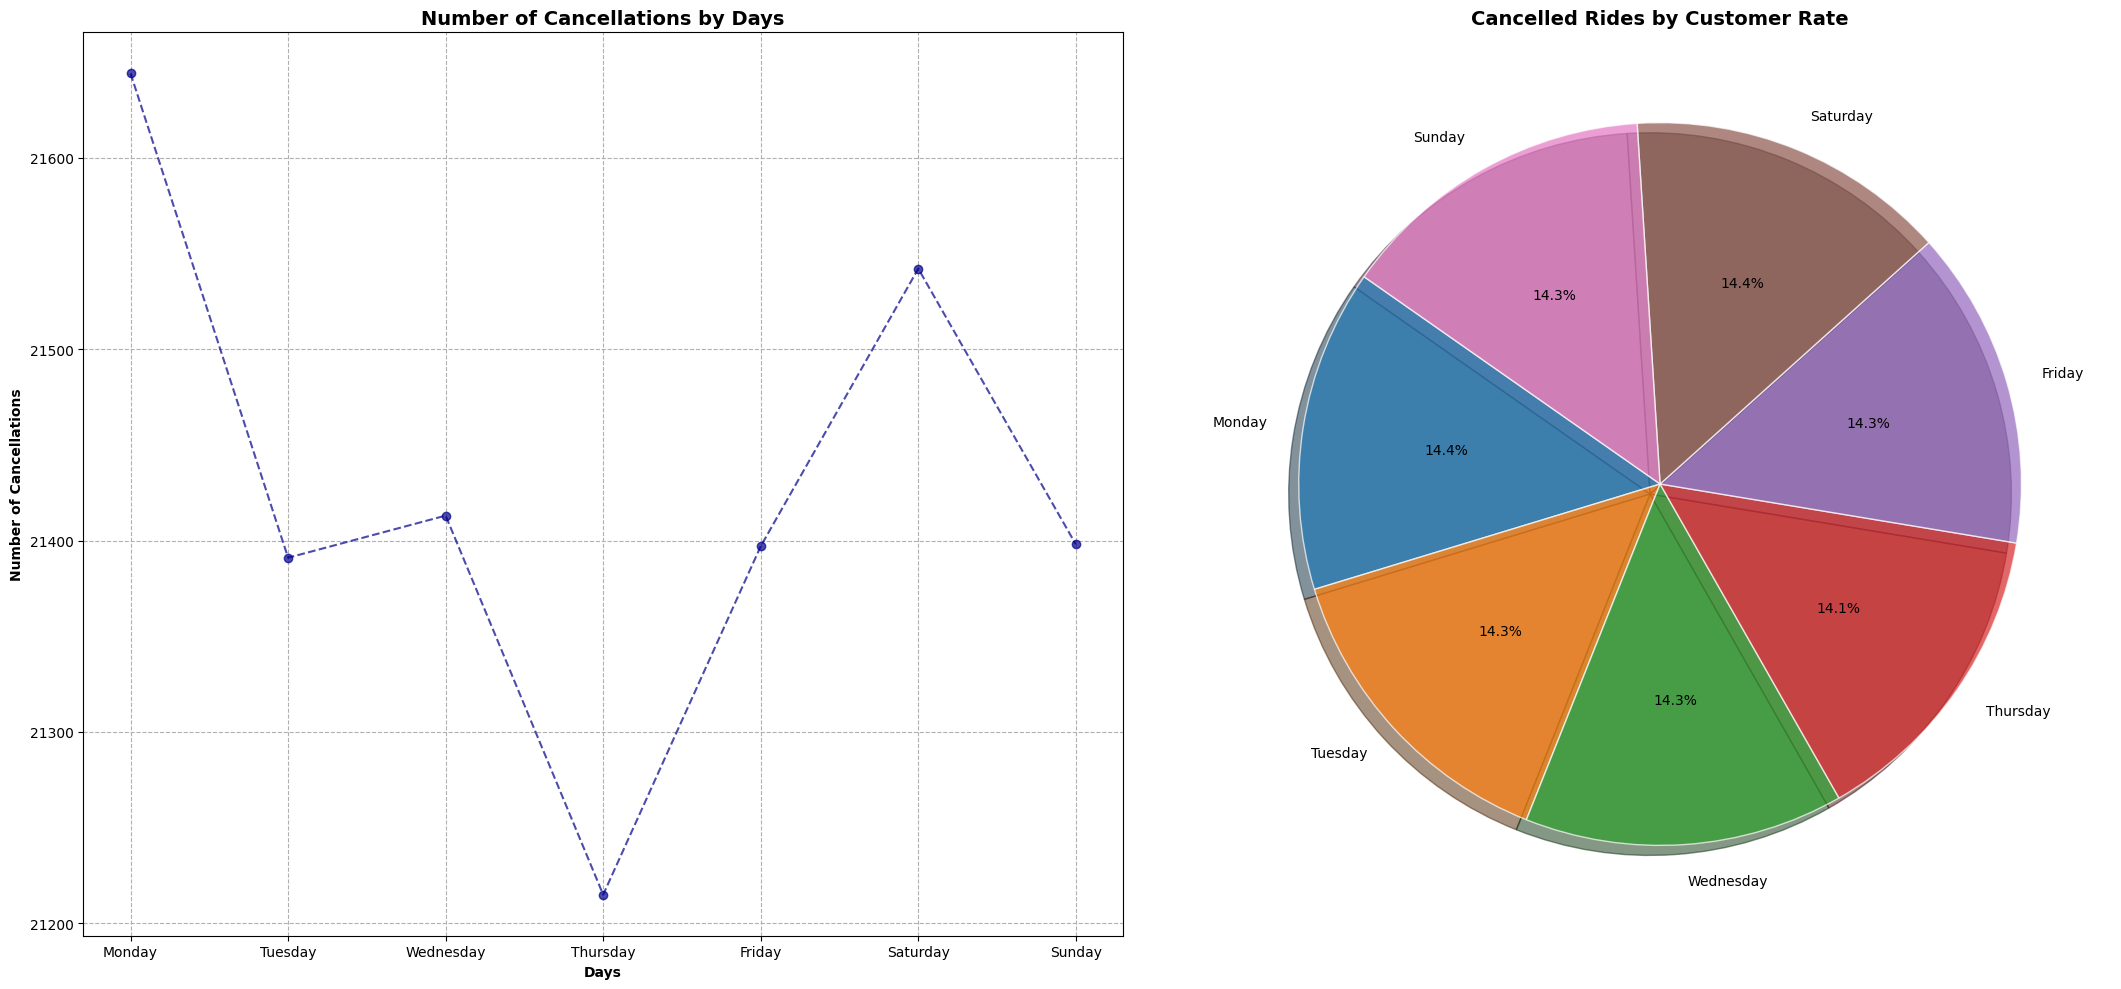

----------------------------------------------------------------------------------------------------


In [36]:
# Cancelled Riders by Customers;
print("Cancelled Riders by Customers;")
print("-"*100)

df['Cancelled Rides by Customer'] = pd.to_numeric(df['Cancelled Rides by Customer'], errors='coerce')
df['Cancelled Rides by Customer'] = df['Cancelled Rides by Customer'].fillna(0.0)

df_clean=df.copy()
df_clean['Datetime']=pd.to_datetime(df_clean['Date'].astype(str)+ ' ' +df_clean['Time'].astype(str))
df_clean['Day']=df_clean["Datetime"].dt.day_name()

day_order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_clean['Day']=pd.Categorical(df_clean['Day'],categories=day_order,ordered=True)

cancelled_rides_by_customers = df_clean.groupby('Day',observed=False)['Cancelled Rides by Customer'].sum()
labels = cancelled_rides_by_customers.index
values = cancelled_rides_by_customers.values

fig,axes=plt.subplots(1,2,figsize=(22,10))
axes[0].plot(labels, values, marker='o', linestyle='--', color='darkblue',alpha=0.7)
axes[0].set_title("Number of Cancellations by Days", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Days", fontsize=10,fontweight='bold')
axes[0].set_ylabel("Number of Cancellations", fontsize=10,fontweight='bold')
axes[0].grid(True, linestyle='--')

axes[1].pie(values, labels=labels, shadow=True,
            autopct='%1.1f%%', startangle=145,
            wedgeprops={"edgecolor": "white", "alpha": 0.7})
axes[1].set_title("Cancelled Rides by Customer Rate", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("Cancelled Rides by Customer.png", dpi=300, bbox_inches='tight')
plt.show()
print("-"*100)

Cancelled Riders by Drivers;
----------------------------------------------------------------------------------------------------


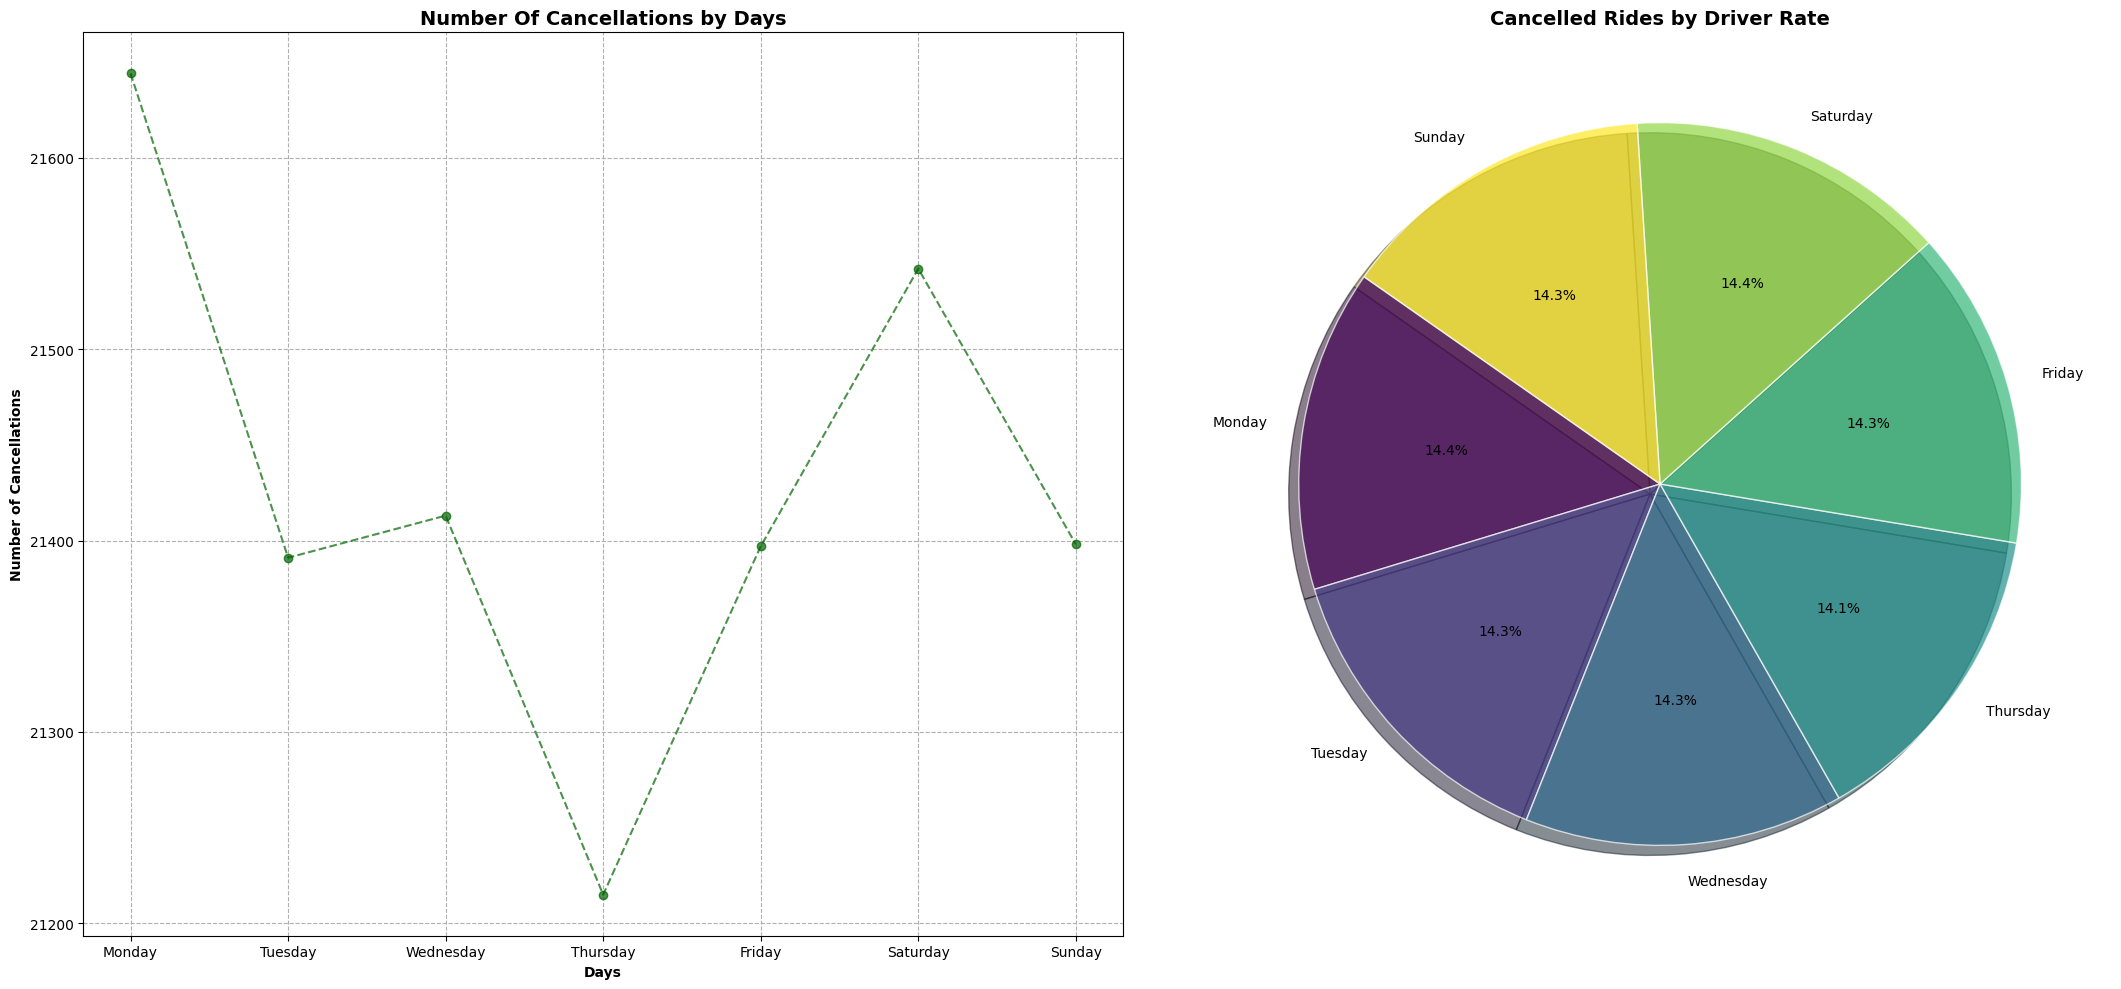

----------------------------------------------------------------------------------------------------


In [37]:
# Cancelled Riders by Drivers;
print("Cancelled Riders by Drivers;")
print("-"*100)


df['Cancelled Rides by Driver'] = pd.to_numeric(df['Cancelled Rides by Driver'], errors='coerce')
df['Cancelled Rides by Driver'] = df['Cancelled Rides by Driver'].fillna(0.0)

cancelled_rides_by_drivers=df_clean.groupby('Day',observed=False)['Cancelled Rides by Driver'].sum()
label=cancelled_rides_by_drivers.index
value=cancelled_rides_by_drivers.values
colors_from_palette=plt.cm.viridis(np.linspace(0,1,len(value)))

fig,axes=plt.subplots(1,2,figsize=(22,10))
axes[0].plot(label,value,marker='o',linestyle="--",color="darkgreen",alpha=0.7)
axes[0].set_title("Number Of Cancellations by Days",fontsize=14,fontweight='bold')
axes[0].set_xlabel("Days",fontsize=10,fontweight='bold')
axes[0].set_ylabel("Number of Cancellations",fontsize=10,fontweight='bold')
axes[0].grid(True,linestyle='--')

axes[1].pie(value,labels=label,shadow=True,autopct='%1.1f%%', colors=colors_from_palette,startangle=145,wedgeprops={"edgecolor":"white","alpha":0.7})
axes[1].set_title("Cancelled Rides by Driver Rate",fontsize=14,fontweight='bold')

plt.tight_layout()
plt.savefig("Cancelled Rides by Driver.png",dpi=300,bbox_inches='tight')
plt.show()
print("-"*100)

Correlation Analysis;
----------------------------------------------------------------------------------------------------


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


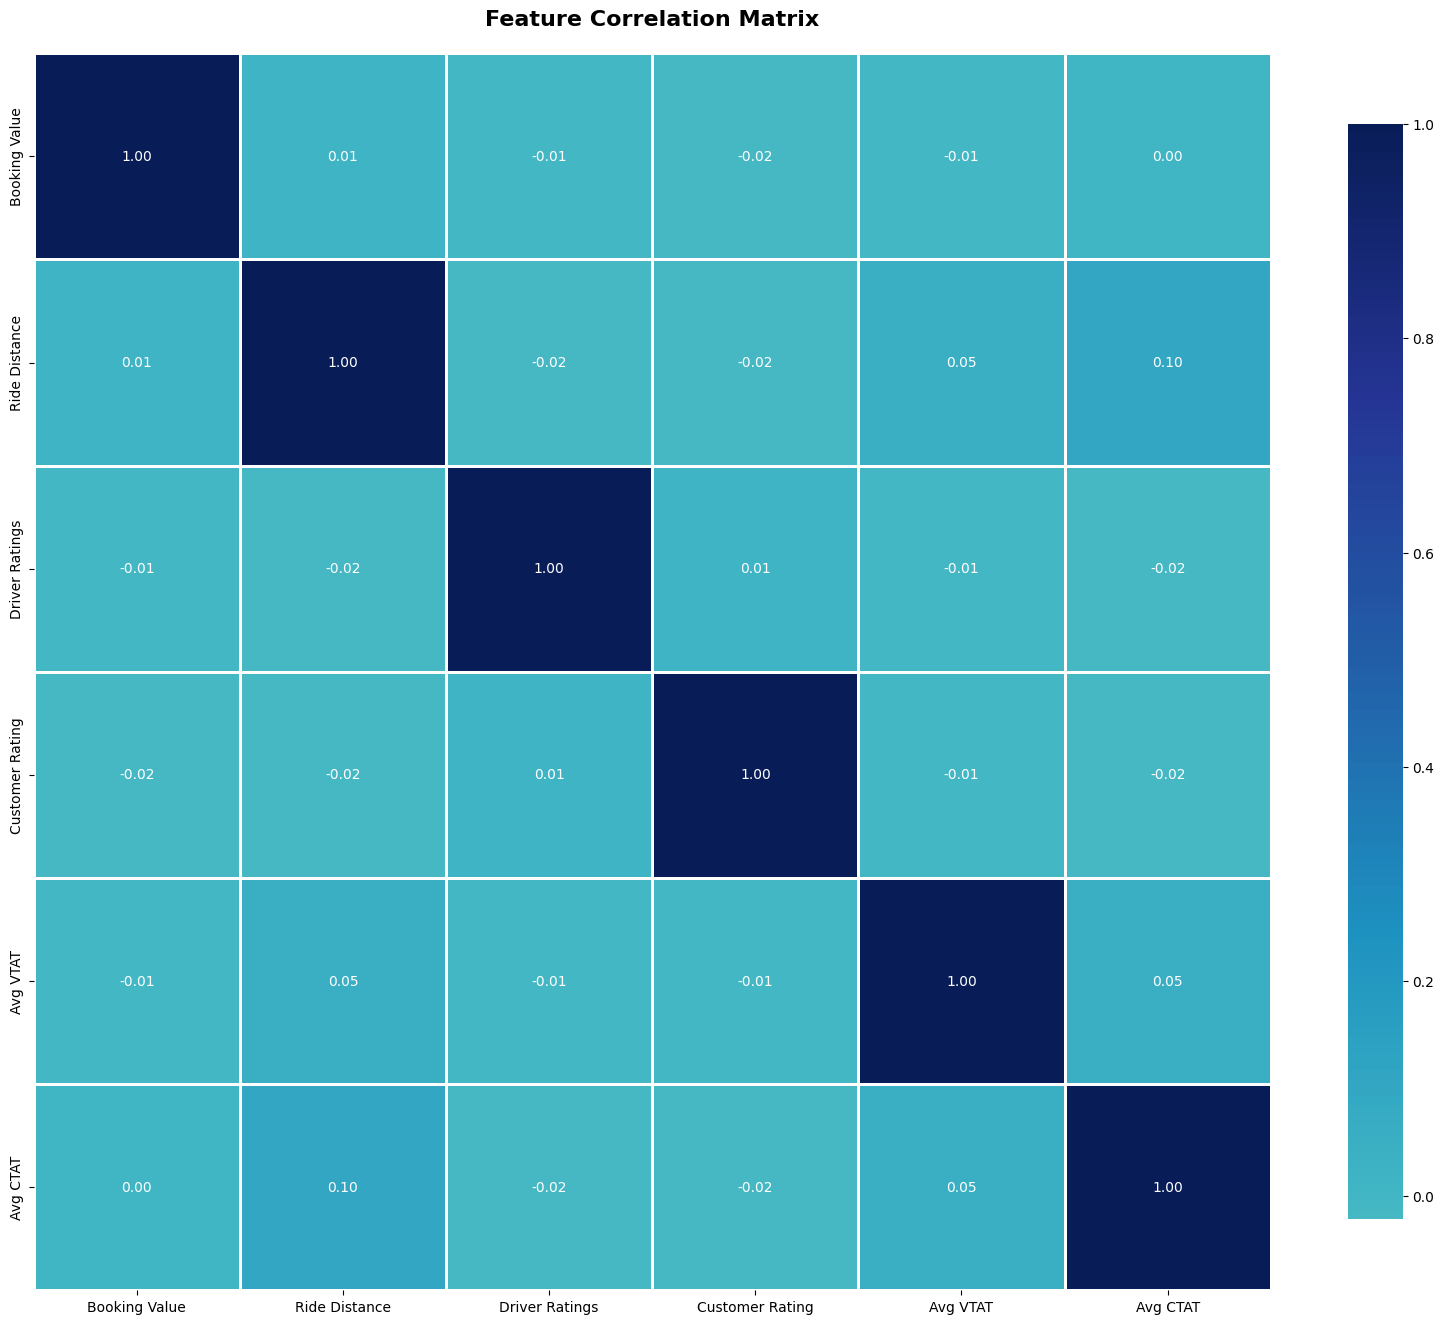

----------------------------------------------------------------------------------------------------


In [38]:
# Correlation Analysis;
print("Correlation Analysis;")
print("-"*100)

numeric_columns = ["Booking Value", "Ride Distance", "Driver Ratings", "Customer Rating","Avg VTAT","Avg CTAT"]
df_numeric = df[numeric_columns].dropna()
correlation=df_numeric.corr()

plt.figure(figsize=(16,14))
mask=np.triu(np.ones_like(correlation,dtype=bool))

sns.heatmap(correlation,annot=True,fmt='.2f', 
            cmap='YlGnBu', center=0, square=True, linewidths=1,
            cbar_kws={"shrink": .8})
plt.title('Feature Correlation Matrix',fontsize=16,fontweight='bold',pad=20)
plt.tight_layout()
plt.savefig("Correlation Matrix.png",dpi=300,bbox_inches='tight')
plt.show()
print("-"*100)


In [39]:
# Multicollinearity Analysis;
print("Multicollinearity Analysis;")
print("-"*100)

high_corr_pairs=[]
for i in range(len(correlation.columns)):
    for j in range(i+1,len(correlation.columns)):
        if abs(correlation.iloc[i,j]>0.8):
            high_corr_pairs.append({'feature-1': correlation.columns[i], 'feature-2': correlation.columns[j], 'correlation': correlation.iloc[i, j]})

if high_corr_pairs:
    high_corr_df=pd.DataFrame(high_corr_pairs)
    print("\nHighly Correlated Feature Pairs (|correlation| > 0.8):")
    print(high_corr_df)
else:
    print("No highly correlated feature pairs found.")

print("-"*100)

Multicollinearity Analysis;
----------------------------------------------------------------------------------------------------
No highly correlated feature pairs found.
----------------------------------------------------------------------------------------------------


In [40]:
# Outlier Analysis;
print("Outlier Analysis;")
print("-"*100)

outlier={}
df_Numeric=df.select_dtypes(include=np.number).copy()

for col in df_Numeric.columns:
    Q1 = df_Numeric[col].quantile(0.25)
    Q3 = df_Numeric[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier[col] = {
        'count': len(outliers),
        'percentage_outliers': (len(outliers) / len(df)) * 100
    }
outlier_df = pd.DataFrame(outlier).T
outlier_df = outlier_df.sort_values(by='count',ascending=False)

print("Outlier (IQR Method):")
print(outlier_df[outlier_df['count'] > 0])
print("-"*100)

Outlier Analysis;
----------------------------------------------------------------------------------------------------
Outlier (IQR Method):
                    count  percentage_outliers
Driver Ratings    51094.0            34.062667
Booking Value     17332.0            11.554667
Customer Rating   10533.0             7.022000
Incomplete Rides   9000.0             6.000000
Avg CTAT           2187.0             1.458000
Avg VTAT            631.0             0.420667
----------------------------------------------------------------------------------------------------


Outlier Analysis Visualization;
----------------------------------------------------------------------------------------------------


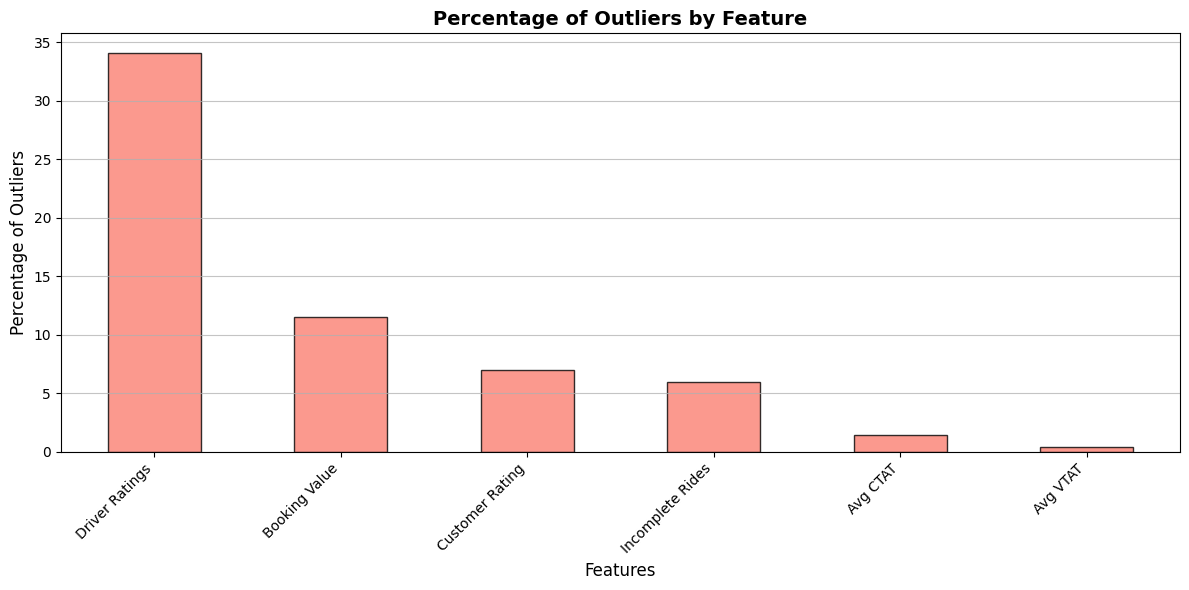

----------------------------------------------------------------------------------------------------


In [41]:
# Outlier Analysis Visualization;
print("Outlier Analysis Visualization;")
print("-"*100)

plt.figure(figsize=(12,6))
outlier_df[outlier_df['count'] > 0]['percentage_outliers'].plot(kind="bar",color='salmon',edgecolor='black',alpha=0.8)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Percentage of Outliers', fontsize=12)
plt.title('Percentage of Outliers by Feature', fontsize=14, fontweight='bold')
plt.xticks(rotation=45,ha='right')
plt.grid(axis='y',alpha=0.75)
plt.tight_layout()
plt.savefig('Outlier_percentage.png', dpi=300, bbox_inches='tight')
plt.show()
print("-"*100)

In [42]:
# Summary Reports;

summary=(f"""
    Total Records:{df.shape[0]}
    Total Features:{df.shape[1]}
    No missing or duplicate values found.         
    Duplicate:{Duplicates}""")


print("Files Saved")
print("- Univariate Analysis.png")
print("- Univariate Analysis2.png")
print("- Vehicle Type.png")
print("- Booking Status.png")
print("- Top and Least 10 Pickup and Drop Location Plots.png")
print("- Driver and Customer Ratings.png")
print("- Customer Ratings and Vehicle Type.png")
print("- Successful Rate.png")
print("- InComplete Reasons.png")
print("- Driver and Customer Points Relationship.png")
print("- Points and Other Feature Relationship.png")
print("- Cancelled Rides by Customer.png")
print("- Cancelled Rides by Driver.png")
print("- Correlation Matrix.png")
print("- Outlier_percentage.png")
print("\nReady for Modeling!")

Files Saved
- Univariate Analysis.png
- Univariate Analysis2.png
- Vehicle Type.png
- Booking Status.png
- Top and Least 10 Pickup and Drop Location Plots.png
- Driver and Customer Ratings.png
- Customer Ratings and Vehicle Type.png
- Successful Rate.png
- InComplete Reasons.png
- Driver and Customer Points Relationship.png
- Points and Other Feature Relationship.png
- Cancelled Rides by Customer.png
- Cancelled Rides by Driver.png
- Correlation Matrix.png
- Outlier_percentage.png

Ready for Modeling!
